In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lobster import *

In [27]:
message_csv  = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_message_5.csv"
orderbook_csv = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_orderbook_5.csv"


msg, ob, qr, df = load_lobster_data(
    message_csv,
    orderbook_csv,
    levels=10,
    K=5
)

/Users/rebeccalaik/Desktop/Imperial/microstructure/DeepQR-Microstructure/lobster.py:215: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  msg["time"] = msg["time"].astype(float)
/Users/rebeccalaik/Desktop/Imperial/microstructure/DeepQR-Microstr

In [28]:
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,100,275150.0,275200.0,166,...,200,275500.0,0,274800.0,661,275600.0,100,274700.0,300,1
1,34200.006462,0.000221,0.000221,L,275500,4,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
2,34200.048864,0.042402,0.042623,C,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
3,34200.048883,0.000020,0.042642,C,275100,-1,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
4,34200.048989,0.000106,0.000125,L,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,0.011408,C,267200,1,34600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580347,57599.860635,0.000191,0.223738,L,267000,-2,16600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580348,57599.870108,0.009473,0.249387,C,267400,3,600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580349,57599.939645,0.069536,0.079201,L,267200,1,100,267150.0,267200.0,88204,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157


In [29]:
aes = compute_aes_by_level(df, K=5)
print(aes)

level
1    483.879182
2    441.553017
3    451.230229
4    475.070075
5    596.928297
Name: AES, dtype: float64


In [30]:
df_norm = normalize_by_aes(df, aes, K=5) #Normalisation des queues

/Users/rebeccalaik/Desktop/Imperial/microstructure/DeepQR-Microstructure/lobster.py:345: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  out[f"{q_prefix}{i}"]  = np.ceil(out[f"{q_prefix}{i}"]  / a).astype("Int64")
/Users/rebeccalaik/Desktop/Im

In [31]:
def shift_orderbook_before_event(df, K):

    df_shift = df.copy()

    for i in range(1, K+1):

        df_shift[f"Q_{i}"] = df_shift[f"Q_{i}"].shift(1)
        df_shift[f"Q_-{i}"] = df_shift[f"Q_-{i}"].shift(1)

    return df_shift

In [32]:
df_qr = shift_orderbook_before_event(df_norm, K=5)

df_qr = df_qr.dropna().reset_index(drop=True)

/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_41363/4163040665.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_shift[f"Q_{i}"] = df_shift[f"Q_{i}"].shift(1)
/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_41363

In [33]:
def build_qr_sequence(df, level):

    q_col = f"Q_{level}"

    seq = pd.DataFrame({
        "eta": df["type"],
        "q": df[q_col],
        "dt": df["dtk_l"]
    })

    seq = seq.dropna()

    return seq

In [34]:
bid1 = build_qr_sequence(df_qr, -1)
ask1 = build_qr_sequence(df_qr, 1)

In [35]:
def qr_mle_from_sequence(seq):

    T = seq.groupby("q")["dt"].sum()

    N = seq.groupby(["q","eta"]).size().unstack(fill_value=0)

    for col in ["L","C","M"]:
        if col not in N.columns:
            N[col] = 0

    N = N[["L","C","M"]]

    lam = N.div(T, axis=0)

    lam["Lambda"] = lam.sum(axis=1)

    return lam.sort_index(), N.sort_index(), T.sort_index()

In [36]:
bid1_lam, bid1_N, bid1_T = qr_mle_from_sequence(bid1)
ask1_lam, ask1_N, ask1_T = qr_mle_from_sequence(ask1)

In [37]:
def plot_qr_intensities(lam, T, title, min_exposure=1.0):

    keep_q = T[T >= min_exposure].index
    lam_f = lam.loc[keep_q].sort_index()

    q = lam_f.index.to_numpy()

    plt.figure(figsize=(10,5))

    plt.plot(q, lam_f["L"], label="λ_L(q)")
    plt.plot(q, lam_f["C"], label="λ_C(q)")
    plt.plot(q, lam_f["M"], label="λ_M(q)")
    plt.plot(q, lam_f["Lambda"], label="Λ(q)")

    plt.xlabel("Queue size q")
    plt.ylabel("Intensity (events/sec)")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.show()

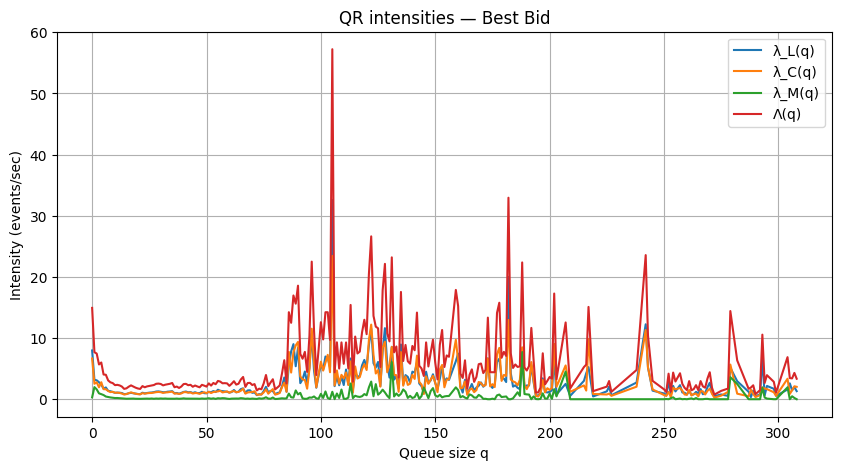

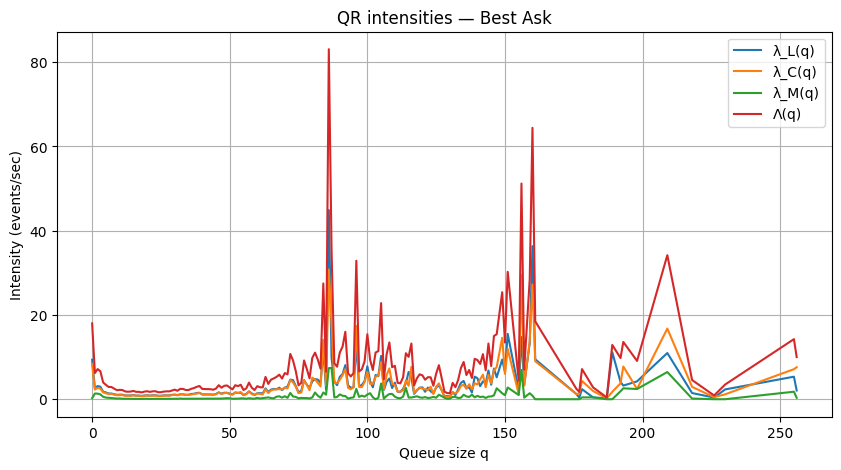

In [38]:
plot_qr_intensities(
    bid1_lam,
    bid1_T,
    "QR intensities — Best Bid"
)

plot_qr_intensities(
    ask1_lam,
    ask1_T,
    "QR intensities — Best Ask"
)

In [39]:
def build_all_sequences(df, K):

    seqs = {}

    for level in range(-K, K+1):

        if level == 0:
            continue

        seqs[level] = build_qr_sequence(df, level)

    return seqs

In [40]:
def estimate_all_qr(seqs):

    lambdas = {}
    Ns = {}
    Ts = {}

    for level, seq in seqs.items():

        lam, N, T = qr_mle_from_sequence(seq)

        lambdas[level] = lam
        Ns[level] = N
        Ts[level] = T

    return lambdas, Ns, Ts

In [41]:
seqs = build_all_sequences(df_qr, K=5)

lambdas, Ns, Ts = estimate_all_qr(seqs)

In [42]:
def plot_all_levels(lambdas, Ts, K):

    for i in range(1, K+1):

        plot_qr_intensities(
            lambdas[-i],
            Ts[-i],
            f"QR intensities — Bid level {i}"
        )

        plot_qr_intensities(
            lambdas[i],
            Ts[i],
            f"QR intensities — Ask level {i}"
        )

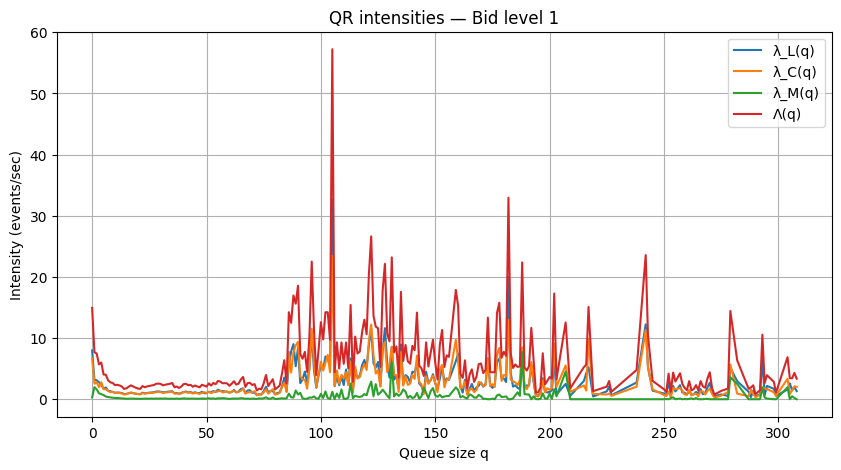

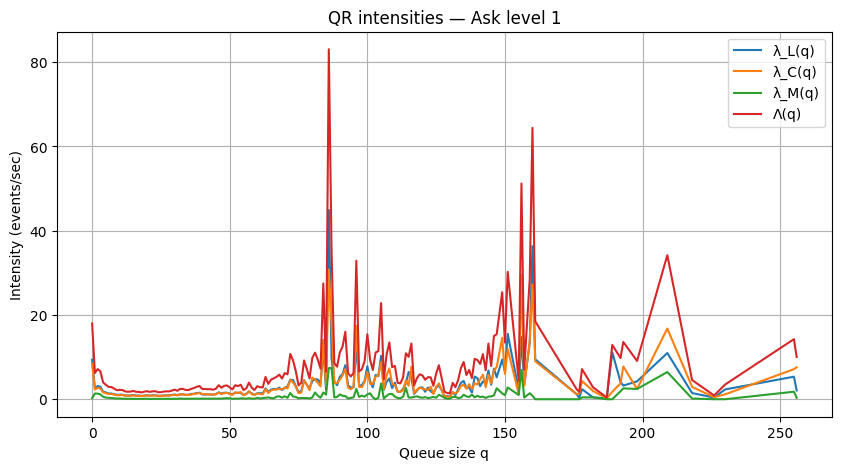

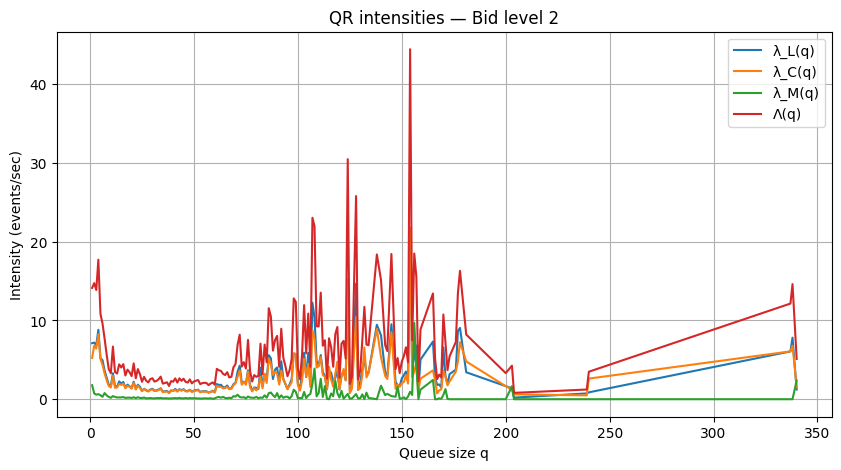

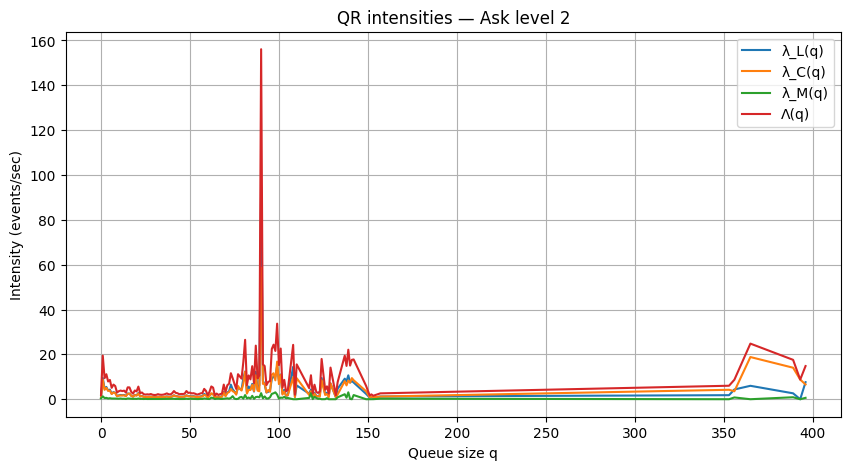

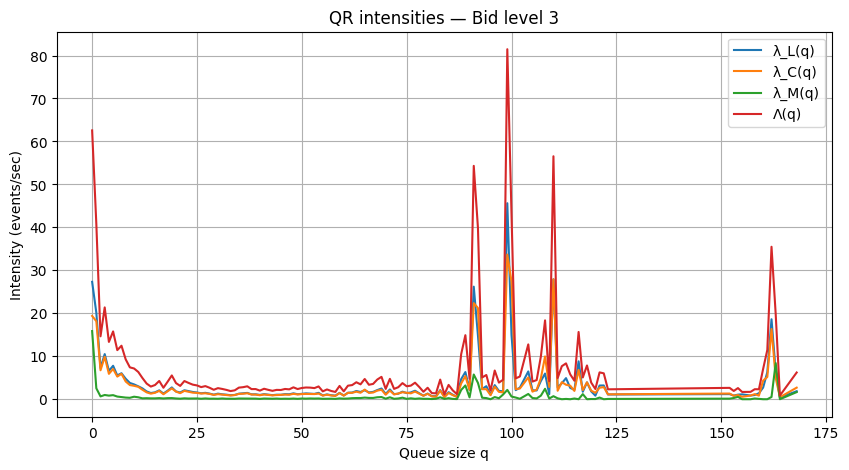

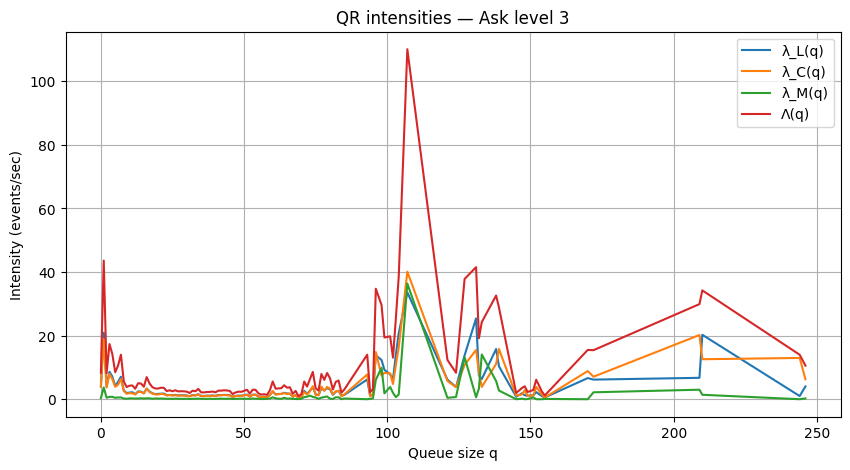

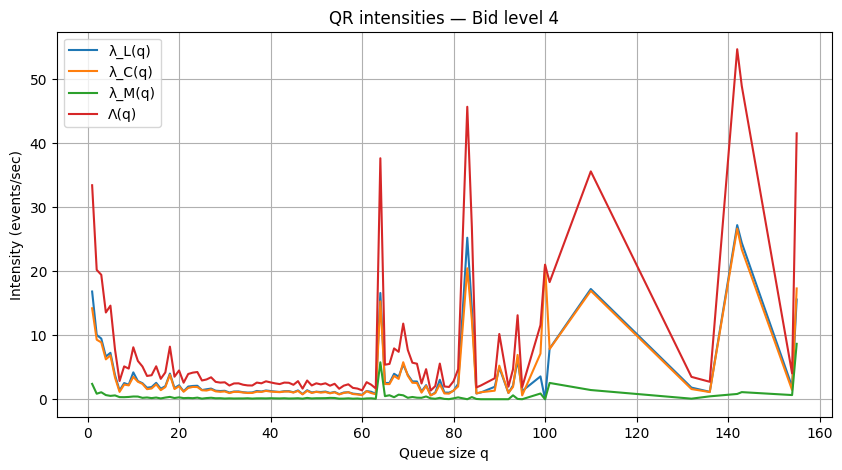

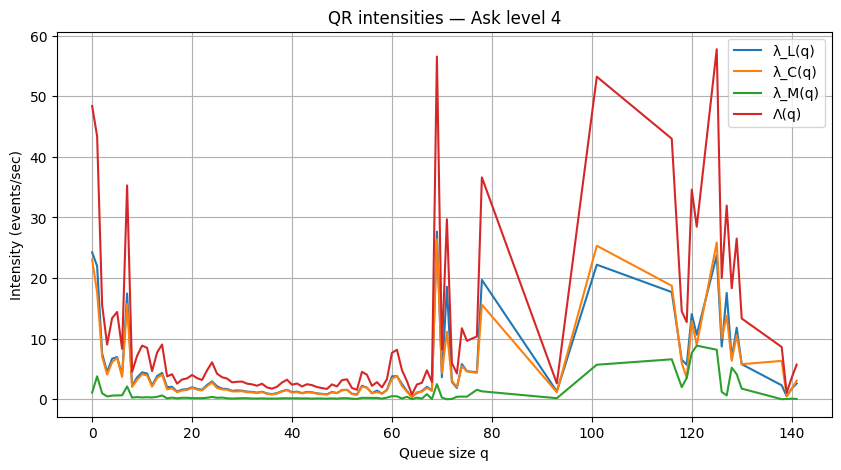

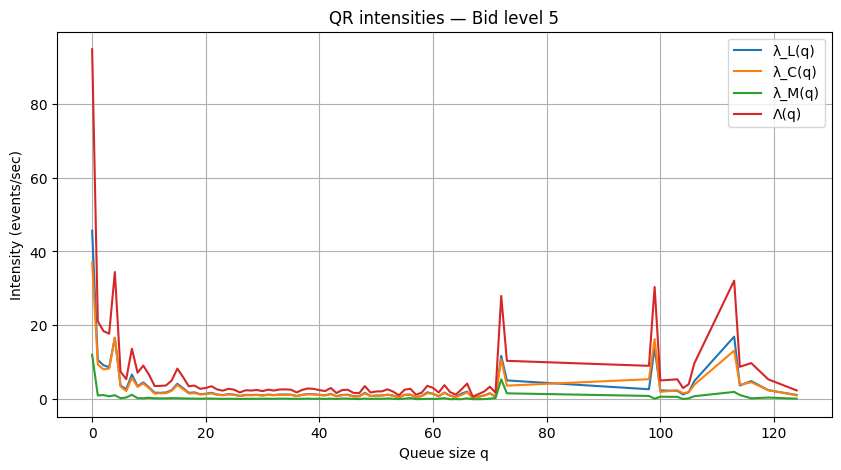

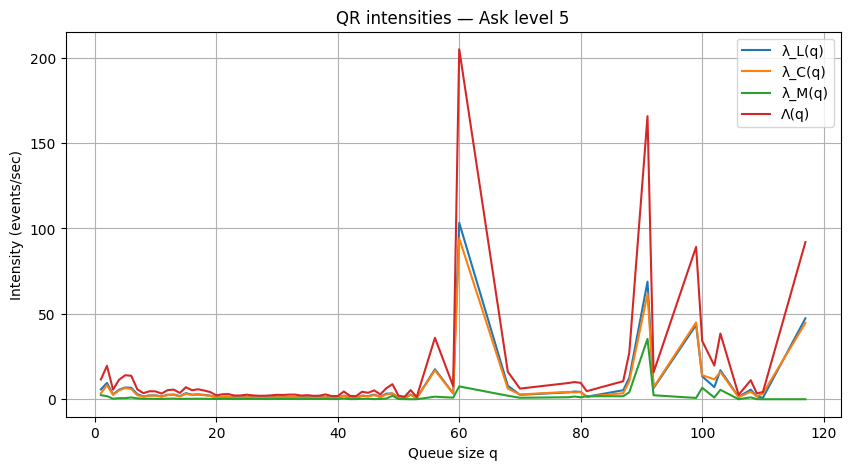

In [43]:
plot_all_levels(lambdas, Ts, K=5)

In [44]:
EVENT_NAME = {"L": "limit", "C": "cancel", "M": "trade"}
RAW_ORDER = ["C", "L", "M"]
FINAL_ORDER = ["cancel", "limit", "trade"]


def real_transition_matrix(df):
    d = df[df["lvl"] != 0].copy()

    # côté de l'événement
    d["side"] = np.where(d["lvl"] > 0, "ask", "bid")

    # précédent événement sur le même côté (intra-side)
    d["prev_type"] = d.groupby("side")["type"].shift(1)

    counts = pd.crosstab(d["prev_type"], d["type"])
    counts = counts.reindex(index=RAW_ORDER, columns=RAW_ORDER, fill_value=0)

    mat = counts.div(counts.sum(axis=1), axis=0)
    mat = mat.rename(index=EVENT_NAME, columns=EVENT_NAME)
    mat = mat.reindex(index=FINAL_ORDER, columns=FINAL_ORDER)

    return mat



In [45]:
def qr_transition_matrix(Ns, K=5):
    # agrège les comptages N(q, eta) sur tous les niveaux et tous les q
    total_counts = pd.Series({"L": 0.0, "C": 0.0, "M": 0.0})

    for level in range(-K, K + 1):
        if level == 0:
            continue

        N = Ns[level].copy()

        for col in ["L", "C", "M"]:
            if col not in N.columns:
                N[col] = 0

        total_counts += N[["L", "C", "M"]].sum(axis=0)

    p = total_counts / total_counts.sum()

    row = pd.Series({
        "cancel": p["C"],
        "limit": p["L"],
        "trade": p["M"]
    })

    mat = pd.DataFrame([row, row, row], index=FINAL_ORDER)
    mat = mat[FINAL_ORDER]

    return mat


In [46]:
def plot_transition_matrix(mat, title, vmin=0.0, vmax=0.8):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(mat.columns)
    ax.set_yticklabels(mat.index)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{mat.iloc[i, j]:.2f}",
                    ha="center", va="center", color="white", fontsize=12)

    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

In [47]:
real_matrix = real_transition_matrix(df)
qr_matrix = qr_transition_matrix(Ns, K=5)

print("REAL MATRIX")
print(real_matrix.round(3))

print("\nQR MATRIX")
print(qr_matrix.round(3))

REAL MATRIX
type       cancel  limit  trade
prev_type                      
cancel      0.447  0.538  0.015
limit       0.499  0.487  0.013
trade       0.162  0.076  0.762

QR MATRIX
        cancel  limit  trade
cancel   0.457  0.487  0.056
limit    0.457  0.487  0.056
trade    0.457  0.487  0.056


/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_41363/2148540095.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  d["side"] = np.where(d["lvl"] > 0, "ask", "bid")
/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_4136

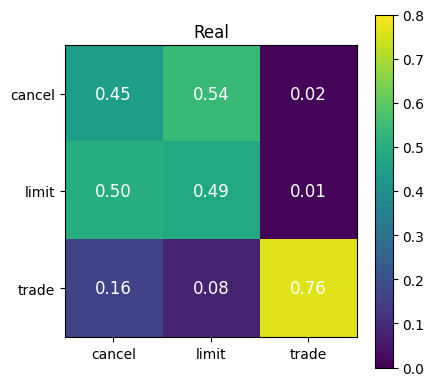

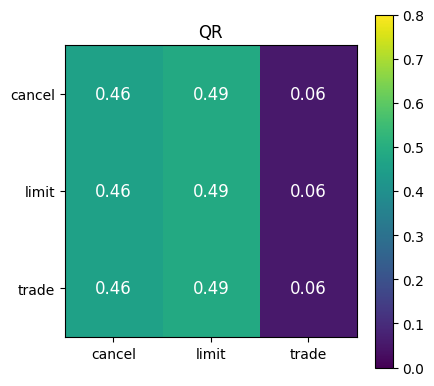

In [ ]:
plot_transition_matrix(real_matrix, "Real")
plot_transition_matrix(qr_matrix, "QR")   